In [1]:
import numpy as np
import scipy
import scipy.integrate
import matplotlib.pyplot as plt
import pyreadr
import pandas as pd
import sympy as sp
import xarray as xa

#import M2 data
M2 = pyreadr.read_r('/Users/anjalishah/Desktop/Senior_Thesis/full_2018_data_M2_Bering_combined_data.RDS')
M2 = M2[None]

In [2]:
# full path to datafiles
filenames = "/Users/anjalishah/Desktop/Senior_Thesis/Data/CERES_data_2018.nc"

# pull out only science variables
names = [
    'adj_sfc_par_diff_all_1h',
    'time'
]

CERES_data = xa.open_dataset(filenames)

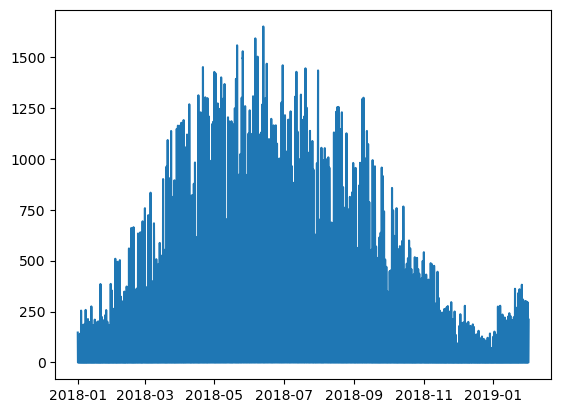

In [3]:
CERES_data_M2 = (CERES_data.adj_sfc_par_direct_all_1h + CERES_data.adj_sfc_par_diff_all_1h).mean(dim='lon') * 4.57 #convert to uE/m^2/s (W/m^2)
CERES_data_M2 = CERES_data_M2.drop('lat') 

plt.plot(CERES_data_M2.time, CERES_data_M2.values)

In [201]:
M2_surf_data = M2['time_ak']
M2_surf_data = M2_surf_data.dt.tz_localize('UTC', ambiguous='True')
M2_surf_data = M2_surf_data.dt.tz_convert('US/Alaska')
M2_surf_dataframe = pd.DataFrame({'time_ak': M2_surf_data, 'approxPAR': M2['approxPAR']})


In [202]:
CERES_data_M2_timeseries = pd.Series(CERES_data_M2.time.values)
CERES_data_M2_timeseries = CERES_data_M2_timeseries.dt.tz_localize('UTC', ambiguous='True')
CERES_data_M2_timeseries = CERES_data_M2_timeseries.dt.tz_convert('US/Alaska')
CERES_data_frame = pd.DataFrame({'time_ak': CERES_data_M2_timeseries, 'approxPAR': CERES_data_M2.values.squeeze()})

In [203]:
end_2018_CERES_M2 = CERES_data_frame[(CERES_data_frame['time_ak'] >= '2018-10-01 20:00:00') & (CERES_data_frame['time_ak'] <= '2019-01-01')]
beg_2018_M2_light = M2_surf_dataframe

/var/folders/mv/05qc0kg10pv1rck13f9ncn6m0000gn/T/ipykernel_89509/2106700032.py:7: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  light_data_2018['time'] = light_data_2018['time'].dt.round('H', ambiguous=True)


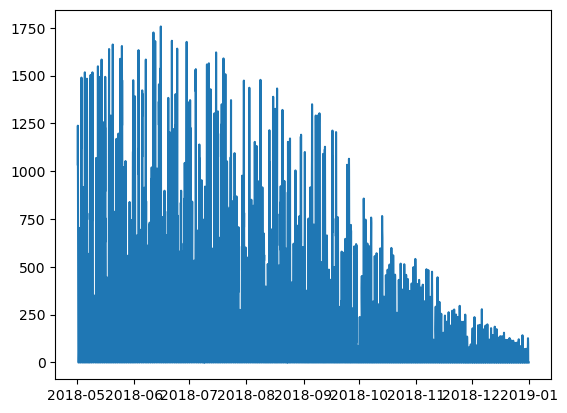

In [210]:
start_time = pd.Timestamp('2018-05-01 09:00:00', tz='US/Alaska')
end_time = pd.Timestamp('2018-12-31 23:59:00', tz='US/Alaska')
light_data_2018 = pd.concat([beg_2018_M2_light, end_2018_CERES_M2])
light_data_2018.set_index(np.arange(0, len(light_data_2018)), inplace=True)
light_data_2018 = light_data_2018.rename(columns={'time_ak': 'time'})
light_data_2018 = light_data_2018[(light_data_2018['time'] >= start_time) & (light_data_2018['time'] <= end_time)] #filter data for correct dates (summer through fall)
light_data_2018['time'] = light_data_2018['time'].dt.round('H', ambiguous=True)

plt.plot(light_data_2018['time'], light_data_2018['approxPAR'])

In [209]:
light_data_2018

,time,approxPAR
0,2018-05-01 15:00:00-08:00,NaN
1,2018-05-01 16:00:00-08:00,1035.6077
2,2018-05-01 17:00:00-08:00,1238.0130
3,2018-05-01 18:00:00-08:00,1047.3983
4,2018-05-01 19:00:00-08:00,646.5179
...,...,...
5854,2018-12-31 19:30:00-09:00,0.0000
5855,2018-12-31 20:29:45.937500032-09:00,0.0000
5856,2018-12-31 21:30:14.062499968-09:00,0.0000
5857,2018-12-31 22:30:00-09:00,0.0000
